In [10]:

import json
import pandas as pd
from geopandas import GeoDataFrame
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask
import rasterstats as rs
import warnings
from tobler.util.util import _check_presence_of_crs

import statsmodels.formula.api as smf
from statsmodels.genmod.families import Poisson, Gaussian

__all__ = [
    "getFeatures",
    "return_area_profile",
    "append_profile_in_gdf",
    "fast_append_profile_in_gdf",
    "return_weights_from_regression",
    "return_weights_from_xgboost",
    "create_lon_lat",
    "create_non_zero_population_by_pixels_locations",
    "calculate_interpolated_polygon_population_from_correspondence_table",
    "calculate_interpolated_population_from_correspondence_table",
]


def getFeatures(gdf):

    """Function to parse features from GeoDataFrame in such a manner that rasterio wants them
    
    Notes
    -----
    This function was obtained at https://automating-gis-processes.github.io/CSC18/lessons/L6/clipping-raster.html.
    
    """

    return [json.loads(gdf.to_json())["features"][0]["geometry"]]


def return_area_profile(polygon, raster, force_crs_match=True):

    """DEPRECATED
    
    Function that counts the amount of pixel types it is inside a polygon within a given raster
    
    Parameters
    ----------
    
    polygon         : polygon for the profile (it can be a row of a geopandas)
    
    raster          : the associated raster (from rasterio.open)
    
    force_crs_match : bool. Default is True.
                      Wheter the Coordinate Reference System (CRS) of the polygon will be reprojected to the CRS of the raster file. 
                      It is recommended to let this argument as True.

    """

    _check_presence_of_crs(polygon)

    if force_crs_match:
        polygon_projected = polygon.to_crs(crs=raster.crs.data)
    else:
        warnings.warn(
            "The polygon is not being reprojected. The clipping might be being performing on unmatching polygon to the raster."
        )

    coords = getFeatures(polygon_projected)
    out_img = mask(dataset=raster, shapes=coords, crop=True)[0]

    x = np.ndarray.flatten(out_img)
    y = np.bincount(x)
    ii = np.nonzero(y)[0]

    profile = pd.DataFrame.from_dict(
        dict(
            zip(
                np.core.defchararray.add("Type_", ii.astype(str)),
                y[ii].reshape(len(y[ii]), 1),
            )
        )
    )  # pandas like

    polygon_with_profile = pd.concat(
        [polygon.reset_index(drop=True), profile], axis=1
    )  # Appends in the end

    return polygon_with_profile


def append_profile_in_gdf(geodataframe, raster, force_crs_match=True):

    """DEPRECATED
    
    Function that appends the columns of the profile in a geopandas according to a given raster
    
    geodataframe    : a GeoDataFrame from geopandas that has overlay with the raster. The variables of the profile will be appended in this data.
                      If some polygon do not overlay the raster, consider a preprocessing step using the function subset_gdf_polygons_from_raster.
    
    raster          : the associated NLCD raster (from rasterio.open).
    
    force_crs_match : bool. Default is True.
                      Wheter the Coordinate Reference System (CRS) of the polygon will be reprojected to the CRS of the raster file. 
                      It is recommended to let this argument as True.
                      
    Notes
    -----
    The generated geodataframe will input the value 0 for each Type that is not present in the raster for each polygon. 
    
    """

    _check_presence_of_crs(geodataframe)

    final_geodata = gpd.GeoDataFrame()

    for i in range(len(geodataframe)):

        aux = return_area_profile(
            geodataframe.iloc[[i]], raster=raster, force_crs_match=force_crs_match
        )
        final_geodata = pd.concat(
            [final_geodata.reset_index(drop=True), aux], axis=0, sort=False
        )  # sort = False means that the profile will be appended in the end of the result
        final_geodata.reset_index(drop=True)
        print(
            "Polygon profile {} appended out of {}".format(i + 1, len(geodataframe)),
            end="\r",
        )

    # Input 0 in Types which are not present in the raster for the polygons
    filter_col = [col for col in final_geodata if col.startswith("Type_")]
    final_geodata[filter_col] = final_geodata[filter_col].fillna(value=0)

    return final_geodata


def fast_append_profile_in_gdf(geodataframe, raster_path, force_crs_match=True):

    """Function that appends the columns of the profile in a geopandas according to a given raster taking advantage of rasterstats
    
    geodataframe    : a GeoDataFrame from geopandas that has overlay with the raster. The variables of the profile will be appended in this data.
                      If some polygon do not overlay the raster, consider a preprocessing step using the function subset_gdf_polygons_from_raster.
    
    raster_path     : the path to the associated raster image.
    
    force_crs_match : bool. Default is True.
                      Wheter the Coordinate Reference System (CRS) of the polygon will be reprojected to the CRS of the raster file. 
                      It is recommended to let this argument as True.
                      
    Notes
    -----
    The generated geodataframe will input the value 0 for each Type that is not present in the raster for each polygon. 
    
    """

    _check_presence_of_crs(geodataframe)
    #raster_path = fetch_quilt_path(raster_path)
    if force_crs_match:
        raster = rasterio.open(raster_path)
        geodataframe = geodataframe.to_crs(crs=raster.crs.data)
    else:
        warnings.warn(
            "The GeoDataFrame is not being reprojected. The clipping might be being performing on unmatching polygon to the raster."
        )

    zonal_gjson = rs.zonal_stats(
        geodataframe, raster_path, prefix="Type_", geojson_out=True, categorical=True
    )

    zonal_ppt_gdf = GeoDataFrame.from_features(zonal_gjson)

    return zonal_ppt_gdf


def return_weights_from_regression(
    geodataframe,
    raster_path,
    pop_string,
    codes=[21, 22, 23, 24],
    likelihood="Poisson",
    n_pixels_option_values=256,
    force_crs_match=True,
    na_value=255,
    ReLU=True,
):

    """Function that returns the weights of each land type according to NLCD types/codes
    
    Parameters
    ----------
    
    geodataframe           : a geopandas geoDataFrame used to build regression
    
    raster_path            : the path to the associated raster image.
    
    pop_string             : the name of the variable on geodataframe that the regression shall be conducted
    
    codes                  : an integer list of codes values that should be considered as 'populated' from the National Land Cover Database (NLCD).
                             The description of each code can be found here: https://www.mrlc.gov/sites/default/files/metadata/landcover.html
                             The default is 21 (Developed, Open Space), 22 (Developed, Low Intensity), 23 (Developed, Medium Intensity) and 24 (Developed, High Intensity).
                             
    likelihood             : the likelihood assumed for the dependent variable (population). 
                             It can be 'Poisson' or 'Gaussian'. 
                             With the 'Poisson' a Generalized Linear Model with log as link function will be fitted and 'Gaussian' an ordinary least squares will be fitted. 
                             
    n_pixels_option_values : number of options of the pixel values of rasterior. Default is 256.
    
    force_crs_match        : bool. Default is True.
                             Wheter the Coordinate Reference System (CRS) of the polygon will be reprojected to the CRS of the raster file. 
                             It is recommended to let this argument as True.
    
    na_value               : int. Default is 255.
                             The number which is considered to be 'Not a Number' (NaN) in the raster pixel values.
                             
    ReLU                   : bool. Default is True.
                             Wheter the Rectified Linear Units (ReLU) transformation will be used to avoid negative weights for the land types.
    
    Notes
    -----
    1) The formula uses a substring called 'Type_' before the code number due to the 'append_profile_in_gdf' function.
    2) The pixel value, usually, ranges from 0 to 255. That is why the default of 'n_pixels_option_values' is 256.
    
    """

    _check_presence_of_crs(geodataframe)
    #raster_path = fetch_quilt_path(raster_path)

    if na_value in codes:
        raise ValueError("codes should not assume the na_value value.")

    if not likelihood in ["Poisson", "Gaussian"]:
        raise ValueError("likelihood must one of 'Poisson', 'Gaussian'")

    print("Appending profile...")
    profiled_df = fast_append_profile_in_gdf(
        geodataframe[["geometry", pop_string]], raster_path, force_crs_match
    )  # Use only two columns to build the weights (this avoids error, if the original dataset has already types appended on it).
    print("Append profile: Done.")

    # If the list is unsorted, the codes will be sorted to guarantee that the position of the weights will match
    codes.sort()

    # Formula WITHOUT intercept
    str_codes = [str(i) for i in codes]
    formula_string = (
        pop_string + " ~ -1 + " + " + ".join(["Type_" + s for s in str_codes])
    )

    print("Starting to fit regression...")
    if likelihood == "Poisson":
        results = smf.glm(formula_string, data=profiled_df, family=Poisson()).fit()

    if likelihood == "Gaussian":
        results = smf.ols(formula_string, data=profiled_df).fit()

    weights = np.zeros(n_pixels_option_values)
    weights[codes] = results.params

    if ReLU:
        weights = np.where(weights < 0, 0, weights)

    return weights


def return_weights_from_xgboost(
    geodataframe,
    raster_path,
    pop_string,
    codes=[21, 22, 23, 24],
    n_pixels_option_values=256,
    tuned_xgb=False,
    gbm_hyperparam_grid={
        "learning_rate": [0.001, 0.01, 0.1],
        "n_estimators": [200],
        "subsample": [0.3, 0.5],
        "max_depth": [4, 5, 6],
        "num_boosting_rounds": [10, 20],
    },
    force_crs_match=True,
    na_value=255,
    ReLU=True,
):

    """Function that returns the weights of each land type according to NLCD types/codes given by Extreme Gradient Boost model (XGBoost)
    
    Parameters
    ----------
    
    geodataframe           : a geopandas geoDataFrame used to build regression
    
    raster_path            : the path to the associated raster image.
    
    pop_string             : the name of the variable on geodataframe that the regression shall be conducted
    
    codes                  : an integer list of codes values that should be considered as 'populated' from the National Land Cover Database (NLCD).
                             The description of each code can be found here: https://www.mrlc.gov/sites/default/files/metadata/landcover.html
                             The default is 21 (Developed, Open Space), 22 (Developed, Low Intensity), 23 (Developed, Medium Intensity) and 24 (Developed, High Intensity).
                             
    n_pixels_option_values : number of options of the pixel values of rasterior. Default is 256.
    
    tuned_xgb              : bool. Default is False.
                             If True the XGBoost model will be tuned making a grid search using gbm_hyperparam_grid dictionary a picking the best model in terms of mean squared error with some pre-defined number of cross-validation.
                             Otherwise, the XGBoost model is fitted with default values of xgboost.train function from xgboost Python library.
                             
    gbm_hyperparam_grid    : a dictionary that represent the grid for the grid search of XGBoost.
    
    force_crs_match        : bool. Default is True.
                             Wheter the Coordinate Reference System (CRS) of the polygon will be reprojected to the CRS of the raster file. 
                             It is recommended to let this argument as True.
    
    na_value               : int. Default is 255.
                             The number which is considered to be 'Not a Number' (NaN) in the raster pixel values.
                             
    ReLU                   : bool. Default is True.
                             Wheter the Rectified Linear Units (ReLU) transformation will be used to avoid negative weights for the land types.
    
    Notes
    -----
    1) The formula uses a substring called 'Type_' before the code number due to the 'append_profile_in_gdf' function.
    2) The pixel value, usually, ranges from 0 to 255. That is why the default of 'n_pixels_option_values' is 256.
    3) The returning weights represent the average of the Shapley's values from each feature.
    
    """
    #raster_path = fetch_quilt_path(raster_path)

    try:
        import xgboost as xgb
        import shap
    except ImportError as e:
        raise ImportError("xgboost and shap are required to perform this.")

    _check_presence_of_crs(geodataframe)

    if na_value in codes:
        raise ValueError("codes should not assume the na_value value.")

    print("Appending profile...")
    profiled_df = fast_append_profile_in_gdf(
        geodataframe[["geometry", pop_string]], raster_path, force_crs_match
    )  # Use only two columns to build the weights (this avoids error, if the original dataset has already types appended on it).
    print("Append profile: Done.")

    # If the list is unsorted, the codes will be sorted to guarantee that the position of the weights will match
    codes.sort()

    str_codes = [str(i) for i in codes]
    feature_names = ["Type_" + s for s in str_codes]

    y = profiled_df[pop_string]
    X = profiled_df[feature_names]

    print("Starting to fit XGBoost...")
    if tuned_xgb == False:

        # Create the DMatrix
        xgb_dmatrix = xgb.DMatrix(X, y)

        # Create the parameter dictionary
        params = {"objective": "reg:linear"}

        # Train the model
        xg_reg = xgb.train(params=params, dtrain=xgb_dmatrix)

    if tuned_xgb == True:

        try:
            from sklearn.model_selection import GridSearchCV
        except ImportError as e:
            raise ImportError("sklearn is required to perform this.")

        gbm = xgb.XGBRegressor()
        grid_mse = GridSearchCV(
            estimator=gbm,
            param_grid=gbm_hyperparam_grid,
            scoring="neg_mean_squared_error",
            cv=4,  # 4-fold crossvalidation
            verbose=3,  # Prints the grid search profile
            n_jobs=-1,
        )  # Process the GridSearch in parallel all cores availables

        # Fit the grid to the data
        grid_mse.fit(X, y)

        best_params = grid_mse.best_params_
        best_params["objective"] = "reg:linear"

        # Create the DMatrix
        xgb_dmatrix = xgb.DMatrix(X, y)

        # Train the model from the best parameters of the grid search
        xg_reg = xgb.train(params=best_params, dtrain=xgb_dmatrix)

    # Build explainer and fit Shapley's values (https://github.com/slundberg/shap)
    explainer = shap.TreeExplainer(xg_reg)
    shap_values = explainer.shap_values(X)
    weights_from_xgb = shap_values.mean(axis=0)  # This is already sorted by pixel Type

    weights = np.zeros(n_pixels_option_values)
    weights[codes] = list(weights_from_xgb)  # Convert to list a dict_values

    if ReLU:
        weights = np.where(weights < 0, 0, weights)

    return weights


def create_lon_lat(out_img, out_transform):

    """Function that returns a tuple of longitudes and latitudes from numpy array and Affline
    
    Parameters
    ----------
    
    out_img       : numpy array generated by the mask function (first tuple element)
    
    out_transform : Affline transformation generated by the mask function (second tuple element)
    
    Notes
    -----
    
    Inside the inner loop there is an important thing to consider which is that the dimensions
    out_img is (1, lat, lon), whereas the Affline transformation gives (lon, lat) (or, accordingly
    to their documentation is (x,y)) that is why it is swapped the indexes. 
    Also, note the repetition in the indexes of (j, j) and (i, i) inside the inner loop.
    
    """

    lons = np.empty(shape=(1, out_img.shape[1], out_img.shape[2]))
    lats = np.empty(shape=(1, out_img.shape[1], out_img.shape[2]))

    for i in range(out_img.shape[1]):
        for j in range(out_img.shape[2]):
            lons[0][i][j] = (out_transform * (j, j))[0]  # Only index j.
            lats[0][i][j] = (out_transform * (i, i))[1]  # Only indexes of longitudes!

    # Return two arrays: one is the longitudes of each pixel and one is the latitudes of each pixel

    return lons, lats


def create_non_zero_population_by_pixels_locations(
    geodataframe, raster, pop_string, weights=None, force_crs_match=True
):

    """Function that returns the actual population of each pixel from a given geodataframe and variable.
    
    geodataframe       : a geopandas dataframe that it is contained in the raster
    
    raster             : the raster used from rasterio
    
    pop_string         : a string of the column name of the geodataframe that the estimation will be made
    
    weights            : vector of weights in each position of the pixel values according 'return_weights_from_regression' function. This must be provided by the user.
    
    force_crs_match    : bool. Default is True.
                         Wheter the Coordinate Reference System (CRS) of the polygon will be reprojected to the CRS of the raster file. 
                         It is recommended to let this argument as True.
    
    """

    _check_presence_of_crs(geodataframe)

    if force_crs_match:
        geodataframe_projected = geodataframe.to_crs(crs=raster.crs.data)
    else:
        warnings.warn(
            "The polygon is not being reprojected. The clipping might be being performing on unmatching polygon to the raster."
        )

    result_pops_array = np.array([])
    result_lons_array = np.array([])
    result_lats_array = np.array([])

    for line_index in range(len(geodataframe_projected)):
        polygon_projected = geodataframe_projected.iloc[[line_index]]

        coords = getFeatures(polygon_projected)

        out_img, out_transform = mask(dataset=raster, shapes=coords, crop=True)

        """Calculating the population for each pixel"""
        trans_numpy = weights[out_img]  # Pixel population from regression
        orig_estimate = polygon_projected[
            pop_string
        ]  # Original Population Value of The polygon
        correction_term = orig_estimate / trans_numpy.sum()
        final_pop_numpy_pre = trans_numpy * np.array(correction_term)

        flatten_final_pop_numpy_pre = np.ndarray.flatten(final_pop_numpy_pre)

        non_zero_pop_index = np.where(flatten_final_pop_numpy_pre != 0)

        final_pop_numpy = flatten_final_pop_numpy_pre[non_zero_pop_index]

        """Retrieving location of each pixel"""
        lons, lats = create_lon_lat(out_img, out_transform)

        final_lons = np.ndarray.flatten(lons)[non_zero_pop_index]
        final_lats = np.ndarray.flatten(lats)[non_zero_pop_index]

        """Append all flattens numpy arrays"""
        result_pops_array = np.append(result_pops_array, final_pop_numpy)
        result_lons_array = np.append(result_lons_array, final_lons)
        result_lats_array = np.append(result_lats_array, final_lats)

        print(
            "Polygon {} processed out of {}".format(line_index + 1, len(geodataframe)),
            end="\r",
        )

    data = {
        "pop_value": result_pops_array,
        "lons": result_lons_array.round().astype(int).tolist(),
        "lats": result_lats_array.round().astype(int).tolist(),
    }

    corresp = pd.DataFrame.from_dict(data)

    return corresp


def calculate_interpolated_polygon_population_from_correspondence_table(
    polygon, raster, corresp_table, force_crs_match=True, na_value=255
):

    """Function that returns the interpolated population of a given polygon according to a correspondence table previous built
    
    Parameters
    ----------
    
    polygon         : polygon for the profile (it can be a row of a geopandas)
    
    raster          : the associated raster (from rasterio.open)
    
    corresp_table   : correspondence table that has the interpolated population for each pixel. This object is created with the function 'create_non_zero_population_by_pixels_locations'.
    
    force_crs_match : bool. Default is True.
                      Wheter the Coordinate Reference System (CRS) of the polygon will be reprojected to the CRS of the raster file. 
                      It is recommended to let this argument as True.
    
    na_value        : int. Default is 255.
                      The number which is considered to be 'Not a Number' (NaN) in the raster pixel values.
    
    Notes
    -----
    When you clip a specific polygon, there are pixels that lie beyond the polygon extent, because the clipping is rectangular. 
    Therefore, the population could be wrongly summed from another spatial unit.
    The solution is to build a pandas and filter the pixels different than 255. This is done during the construction of the polygon summary for the resulting population of this function.
    
    """

    _check_presence_of_crs(polygon)

    if force_crs_match:
        polygon_projected = polygon.to_crs(crs=raster.crs.data)
    else:
        warnings.warn(
            "The polygon is not being reprojected. The clipping might be being performing on unmatching polygon to the raster."
        )

    coords = getFeatures(polygon_projected)
    out_img, out_transform = mask(dataset=raster, shapes=coords, crop=True)
    lons, lats = create_lon_lat(out_img, out_transform)
    data = {
        "lons": np.ndarray.flatten(lons).round().astype(int).tolist(),
        "lats": np.ndarray.flatten(lats).round().astype(int).tolist(),
        "pixel_value": np.ndarray.flatten(out_img),
    }
    polygon_summary_full = pd.DataFrame.from_dict(data)

    # Remove pixels of the polygon that do not belong to the spatial unit, but might be from another one
    polygon_summary = polygon_summary_full[polygon_summary_full.pixel_value != na_value]

    merged_polygon = corresp_table.merge(polygon_summary, on=["lons", "lats"])

    pop = merged_polygon["pop_value"].sum()

    return pop


def calculate_interpolated_population_from_correspondence_table(
    geodataframe, raster, corresp_table, force_crs_match=True
):

    """Function that returns the interpolated population of an entire geopandas according to a correspondence table previous built
    
    Parameters
    ----------
    
    geodataframe    : a GeoDataFrame from geopandas
    
    raster          : the associated raster (from rasterio.open)
    
    corresp_table   : correspondence table that has the interpolated population for each pixel. This object is created with the function 'create_non_zero_population_by_pixels_locations'.
    
    force_crs_match : bool. Default is True.
                      Wheter the Coordinate Reference System (CRS) of the polygon will be reprojected to the CRS of the raster file. 
                      It is recommended to let this argument as True.
    
    Notes
    -----
    This function returns the same GeoDataFrame used as input with the addition of a new variable called 'interpolated_population', which is the resulting population.
    
    """

    _check_presence_of_crs(geodataframe)

    final_geodataframe = geodataframe.copy()
    pop_final = np.empty(len(geodataframe))

    for line_index in range(len(geodataframe)):
        polygon = geodataframe.iloc[[line_index]]
        pop_aux = calculate_interpolated_polygon_population_from_correspondence_table(
            polygon, raster, corresp_table, force_crs_match
        )
        pop_final[line_index] = pop_aux

        print(
            "Polygon {} processed out of {}".format(line_index + 1, len(geodataframe)),
            end="\r",
        )

    final_geodataframe["interpolated_population"] = pop_final

    return final_geodataframe


def subset_gdf_polygons_from_raster(geodataframe, raster, force_crs_match=True):
    """Function that returns only the polygons that actually have some intersection with a given raster
    
    Parameters
    ----------
    
    geodataframe    : a GeoDataFrame from geopandas
    
    raster          : the associated raster (from rasterio.open)
    
    force_crs_match : bool. Default is True.
                      Wheter the Coordinate Reference System (CRS) of the polygon will be reprojected to the CRS of the raster file. 
                      It is recommended to let this argument as True.

    """

    _check_presence_of_crs(geodataframe)

    if force_crs_match:
        reprojected_gdf = geodataframe.to_crs(crs=raster.crs.data)
    else:
        warnings.warn(
            "The geodataframe is not being reprojected. The clipping might be being performing on unmatching polygon to the raster."
        )

    # has_intersection is a boolean vector: True if the polygon has some overlay with raster, False otherwise
    has_intersection = []
    for i in list(range(len(reprojected_gdf))):
        print("Polygon {} checked out of {}".format(i, len(reprojected_gdf)), end="\r")
        coords = getFeatures(reprojected_gdf.iloc[[i]])
        try:
            out_img = mask(dataset=raster, shapes=coords, crop=True)[0]
            has_intersection.append(True)
        except:
            has_intersection.append(False)

    overlayed_subset_gdf = reprojected_gdf.iloc[has_intersection]
    overlayed_subset_gdf = overlayed_subset_gdf.set_geometry("geometry")

    return overlayed_subset_gdf

In [11]:
# Flowerden 1989: modelagem de Poisson (dados de contagem): Variáveis extensive
# Flowerden 1992: modelagem pra dados normais: Variáveis intensive

# To force the estimates to
#satisfy the pycnophylactic property, the source zone estimates
#were scaled by a factor equal to the ratio of the observed value
#to the Ž tted value. Estimated counts for each target unit were
#then obtained by adding the estimates of each subunit com-
#posing the target unit. <- this is exactly the correction term!

#pg 643 de Combining_Incompatible_Spatial_Data

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.examples import load_example

from tobler.area_weighted import area_interpolate
from tobler.dasymetric import masked_area_interpolate
from tobler.model import glm
from quilt3 import Package

c1 = load_example("Charleston1")
c2 = load_example("Charleston2")

crs = 6569  # https://epsg.io/6569

tracts = gpd.read_file(c1.get_path("sc_final_census2.shp")).to_crs(crs)
zip_codes = gpd.read_file(c2.get_path("CharlestonMSA2.shp")).to_crs(crs)

results_dasy = masked_area_interpolate(
    raster="nlcd_2011.tif",
    source_df=tracts,
    target_df=zip_codes,
    pixel_values = [21,22,23,24],
    extensive_variables=["EMP_MALE"],
)


results_glm = glm(
    raster="nlcd_2011.tif",
    source_df=tracts,
    target_df=zip_codes,
    #pixel_values = [21,22,23,24], # The argument name here is different
    raster_codes = [21,22,23,24],
    variable="EMP_MALE",
    return_model=True
)

C:\Users\renan\anaconda3\Lib\site-packages\pyogrio\core.py:36: RuntimeWarning: Could not detect PROJ data files. Set PROJ_LIB environment variable to the correct path.
  _init_proj_data()
C:\Users\renan\anaconda3\Lib\site-packages\rasterstats\io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(
C:\Users\renan\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [12]:
weights = return_weights_from_regression(tracts, "nlcd_2011.tif", 'EMP_MALE')
weights

Appending profile...
Append profile: Done.
Starting to fit regression...


array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00158811, 0.        , 0.00250673,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [14]:
nlcd_raster = rasterio.open("nlcd_2011.tif")

In [15]:
correspondence_table = create_non_zero_population_by_pixels_locations(tracts, nlcd_raster, 'EMP_MALE', weights)

Polygon 117 processed out of 117

In [16]:
interpolated_pa = calculate_interpolated_population_from_correspondence_table(zip_codes, nlcd_raster, correspondence_table)

ValueError: GeoDataFrame cannot contain duplicated column names.

In [17]:
def calculate_interpolated_polygon_population_from_correspondence_table(
    polygon, raster, corresp_table, force_crs_match=True, na_value=255
):
    """Function that returns the interpolated population of a given polygon according to a correspondence table previous built
    
    Parameters
    ----------
    
    polygon         : polygon for the profile (it can be a row of a geopandas)
    
    raster          : the associated raster (from rasterio.open)
    
    corresp_table   : correspondence table that has the interpolated population for each pixel. This object is created with the function 'create_non_zero_population_by_pixels_locations'.
    
    force_crs_match : bool. Default is True.
                      Wheter the Coordinate Reference System (CRS) of the polygon will be reprojected to the CRS of the raster file. 
                      It is recommended to let this argument as True.
    
    na_value        : int. Default is 255.
                      The number which is considered to be 'Not a Number' (NaN) in the raster pixel values.
    
    Notes
    -----
    When you clip a specific polygon, there are pixels that lie beyond the polygon extent, because the clipping is rectangular. 
    Therefore, the population could be wrongly summed from another spatial unit.
    The solution is to build a pandas and filter the pixels different than 255. This is done during the construction of the polygon summary for the resulting population of this function.
    
    """

    _check_presence_of_crs(polygon)

    if force_crs_match:
        polygon_projected = polygon.to_crs(crs=raster.crs.data)
    else:
        warnings.warn(
            "The polygon is not being reprojected. The clipping might be being performing on unmatching polygon to the raster."
        )

    coords = getFeatures(polygon_projected)
    out_img, out_transform = mask(dataset=raster, shapes=coords, crop=True)
    lons, lats = create_lon_lat(out_img, out_transform)
    data = {
        "lons": np.ndarray.flatten(lons).round().astype(int).tolist(),
        "lats": np.ndarray.flatten(lats).round().astype(int).tolist(),
        "pixel_value": np.ndarray.flatten(out_img),
    }
    polygon_summary_full = pd.DataFrame.from_dict(data)

    # Remove pixels of the polygon that do not belong to the spatial unit, but might be from another one
    polygon_summary = polygon_summary_full[polygon_summary_full.pixel_value != na_value]

    # Check for duplicate columns in corresp_table before merging
    # This ensures we don't have duplicate column names in the merge result
    if len(corresp_table.columns) != len(set(corresp_table.columns)):
        # Remove duplicate columns from corresp_table
        corresp_table = corresp_table.loc[:, ~corresp_table.columns.duplicated()]
    
    # Use suffixes to avoid duplicate column names during merge
    merged_polygon = corresp_table.merge(
        polygon_summary, 
        on=["lons", "lats"],
        suffixes=('', '_polygon')  # Empty suffix for corresp_table columns, _polygon for polygon_summary
    )

    pop = merged_polygon["pop_value"].sum()

    return pop

In [18]:
interpolated_pa = calculate_interpolated_population_from_correspondence_table(zip_codes, nlcd_raster, correspondence_table)

ValueError: GeoDataFrame cannot contain duplicated column names.

In [2]:
# Internal of masked:

In [3]:
from tobler.dasymetric.raster_tools import extract_raster_features

In [4]:
from tobler.dasymetric import _fast_append_profile_in_gdf

In [5]:
raster_mask = extract_raster_features(tracts, "nlcd_2011.tif", pixel_values = [21,22,23,24], collapse_values=False)

In [6]:
type(raster_mask)

geopandas.geodataframe.GeoDataFrame

In [7]:
raster_mask.head()

,value,geometry
0,22.0,"POLYGON ((1473075 1282575, 1473105 1282575, 14..."
1,23.0,"POLYGON ((1473075 1282545, 1473105 1282545, 14..."
2,21.0,"POLYGON ((1473105 1282545, 1473135 1282545, 14..."
3,23.0,"POLYGON ((1473075 1282455, 1473105 1282455, 14..."
4,22.0,"POLYGON ((1473045 1282485, 1473105 1282485, 14..."


<Axes: >

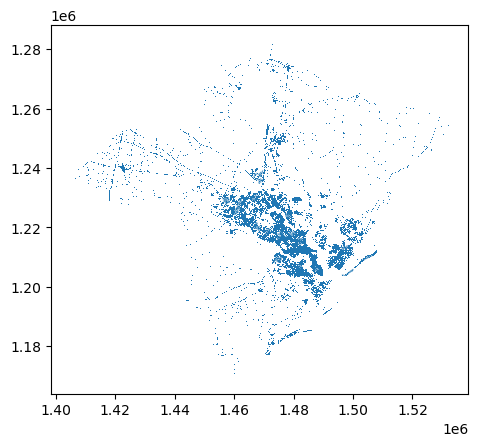

In [8]:
raster_mask.plot()

In [14]:
tracts.shape

(117, 31)

In [15]:
raster_mask.shape

(127687, 2)

In [9]:
profiled_df = _fast_append_profile_in_gdf(
        tracts, "nlcd_2011.tif"
    )

In [10]:
profiled_df.head()

,geometry,FIPS,MSA,TOT_POP,POP_16,POP_65,WHITE_,BLACK_,ASIAN_,HISP_,...,Type_31,Type_41,Type_42,Type_43,Type_52,Type_71,Type_81,Type_82,Type_90,Type_95
0,"POLYGON ((1494925.111 1268225.174, 1494883.339...",45015020200,Charlesto,7665,2083,983,2101,5427,30,54,...,8311.0,6109.0,62438.0,5683.0,45077.0,5846.0,32464.0,14788.0,204328.0,13998.0
1,"POLYGON ((1469751.085 1260803.204, 1469719.283...",45015020100,Charlesto,7291,1501,739,2899,4259,24,26,...,774.0,3295.0,128216.0,4244.0,71430.0,22573.0,33756.0,14921.0,129590.0,6421.0
2,"POLYGON ((1496462.815 1267598.077, 1496429.301...",45015020300,Charlesto,8481,2027,1110,6120,2204,10,66,...,168.0,783.0,102216.0,5327.0,27928.0,6335.0,22120.0,6630.0,128536.0,7630.0
3,"POLYGON ((1430167.432 1229737.323, 1430159.45 ...",45035010300,Charlesto,5503,1293,729,2853,2528,35,28,...,5216.0,3566.0,98706.0,5773.0,51188.0,13572.0,34471.0,38168.0,176153.0,9668.0
4,"POLYGON ((1525398.224 1260307.365, 1525426.044...",45015020401,Charlesto,3820,877,447,2211,1541,0,5,...,1175.0,1107.0,321167.0,10007.0,70870.0,6478.0,17488.0,3884.0,434327.0,29514.0


<Axes: >

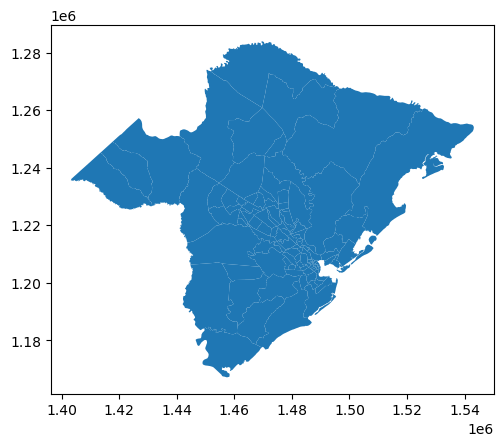

In [11]:
profiled_df.plot()

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.examples import load_example

from tobler.area_weighted import area_interpolate
from tobler.dasymetric import masked_area_interpolate
from tobler.model import glm
from quilt3 import Package

c1 = load_example("Charleston1")
c2 = load_example("Charleston2")

crs = 6569  # https://epsg.io/6569

tracts = gpd.read_file(c1.get_path("sc_final_census2.shp")).to_crs(crs)
zip_codes = gpd.read_file(c2.get_path("CharlestonMSA2.shp")).to_crs(crs)


results_area = area_interpolate(
    source_df=tracts,
    target_df=zip_codes,
    extensive_variables=["EMP_MALE"],
)


results_dasy = masked_area_interpolate(
    raster="nlcd_2011.tif",
    source_df=tracts,
    target_df=zip_codes,
    pixel_values = [21,22,23,24],
    extensive_variables=["EMP_MALE"],
)
print(tracts['EMP_MALE'].sum())
print(results_area['EMP_MALE'].sum())
print(results_dasy['EMP_MALE'].sum())

128317
126431.99958410296
126432.00040152704


In [14]:
results_area.head()

,EMP_MALE,geometry
0,1386.002462,"POLYGON ((705945.04 184157.035, 706550.696 184..."
1,316.242787,"POLYGON ((689232.433 173118.41, 689268.102 173..."
2,18.937561,"POLYGON ((650369.615 162054.012, 650141.565 16..."
3,47.577725,"POLYGON ((675797.612 160560.778, 674663.566 15..."
4,1099.362877,"POLYGON ((715201.738 154387.661, 713683.521 15..."


In [15]:
results_dasy.head()

,EMP_MALE,geometry
0,1058.597450,"POLYGON ((705945.04 184157.035, 706550.696 184..."
1,393.691083,"POLYGON ((689232.433 173118.41, 689268.102 173..."
2,40.202535,"POLYGON ((650369.615 162054.012, 650141.565 16..."
3,61.504025,"POLYGON ((675797.612 160560.778, 674663.566 15..."
4,1161.666968,"POLYGON ((715201.738 154387.661, 713683.521 15..."


In [ ]:
- Fast append profile
- Fit the regression
- Adjust before to return the pixel types and use the extract_raster_features
- Apply correction term for each pixel

In [38]:
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Gaussian, NegativeBinomial, Poisson

In [42]:
source_df = tracts
variable = 'EMP_MALE'
raster = 'nlcd_2011.tif'
raster_codes = [21,22,23,24]
force_crs_match = True
liks = {"poisson": Poisson, "gaussian": Gaussian, "neg_binomial": NegativeBinomial}
likelihood="poisson"

In [43]:
str_codes = [str(i) for i in raster_codes]

formula = (
        variable + " ~ -1 + " + " + ".join(["Type_" + s for s in str_codes])
    )

In [44]:
profiled_df = _fast_append_profile_in_gdf(
        source_df[[source_df.geometry.name, variable]], raster, force_crs_match
    )

results = smf.glm(formula, data=profiled_df, family=liks[likelihood]()).fit()

In [46]:
raster_mask = extract_raster_features(tracts, "nlcd_2011.tif", pixel_values = [21,22,23,24], collapse_values=False)

<Axes: >

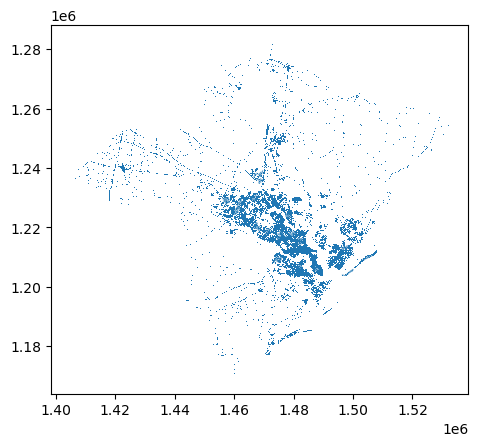

In [48]:
raster_mask.plot()

In [49]:
raster_mask.head()

,value,geometry
0,22.0,"POLYGON ((1473075 1282575, 1473105 1282575, 14..."
1,23.0,"POLYGON ((1473075 1282545, 1473105 1282545, 14..."
2,21.0,"POLYGON ((1473105 1282545, 1473135 1282545, 14..."
3,23.0,"POLYGON ((1473075 1282455, 1473105 1282455, 14..."
4,22.0,"POLYGON ((1473045 1282485, 1473105 1282485, 14..."
